In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.utils import load_sweep_metadata, load_data
import pandas as pd
import torch


In [69]:
from analysis.utils import load_sweep_metadata, load_data

CKPT_TO_USE = 500_000
df_metadata = load_sweep_metadata(
    #"/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-22-cartpole_swingup-projected_sweep",
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-23-cartpole_swingup-projected_sweep_uniform_data",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

# df['ckpt_int'] = df['checkpoint'].apply(
#     lambda x: int(x.split('/')[-1].split('.')[0]))
# # df['angle_degrees'] = df['initial_state'].apply(lambda x: np.degrees(x[1]))
# # #df = df[~df['angle_degrees'].isin([0.0, 360.0])]

# df = df[df['ckpt_int'] == CKPT_TO_USE]
# z_inpolicy = np.concatenate(df['latent_states'].tolist())
# obs_inpolicy = np.concatenate(df['observations'].tolist())
# actions_inpolicy = np.concatenate(df['actions'].tolist())

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-23-cartpole_swingup-projected_sweep_uniform_data:   0%|          | 0/225 [00:00<?, ?it/s]

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-23-cartpole_swingup-projected_sweep_uniform_data: 100%|██████████| 225/225 [00:00<00:00, 3626.38it/s]


Found 224 configurations
Found 224 configurations


100%|██████████| 224/224 [00:01<00:00, 138.11it/s]


In [70]:
df['method_name'] = df['config_name'].apply(lambda x: x.split('_')[0])

In [71]:
df['angle_degrees'] = df['initial_state'].apply(lambda x: int(np.degrees(x[1])))


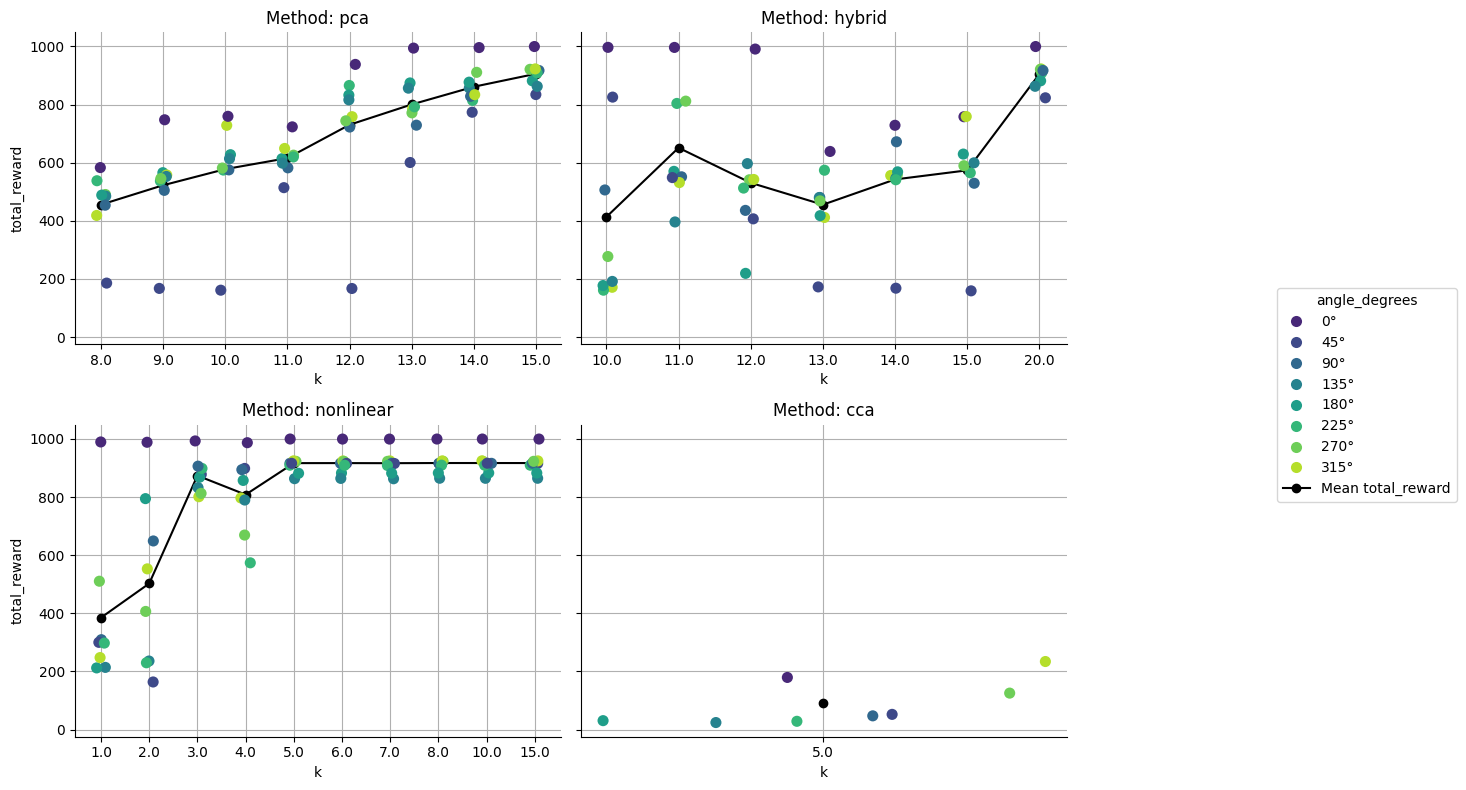

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Filter out 'baseline' method
methods_to_plot = [
    m for m in df['method_name'].unique() if m.lower() != 'baseline'
]

n_methods = len(methods_to_plot)
n_cols = 2
n_rows = (n_methods + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols + 2.5, 4 * n_rows),  # Add width for legend
    sharey=True)

# Flatten in case axes is 2D, also works if 1D
axes = axes.flatten() if n_methods > 1 else [axes]

# --- Order angle categories ---
# Get sorted unique angles
unique_angles_ordered = sorted(df['angle_degrees'].unique())
angle_labels_ordered = [f"{int(a)}°" for a in unique_angles_ordered]

# Categorize angle_degrees with ordered categories
df['angle_degrees_cat'] = pd.Categorical(
    df['angle_degrees'].astype(int).astype(str) + "°",
    categories=angle_labels_ordered,
    ordered=True)

# For color consistency: generate color palette for unique angles
palette = sns.color_palette('viridis', n_colors=len(unique_angles_ordered))
angle_to_color = dict(zip(angle_labels_ordered, palette))

legend_handles = None
legend_labels = None

for idx, (ax, method) in enumerate(zip(axes, methods_to_plot)):
    method_df = df[df['method_name'] == method]

    # Determine the sorted order used for x-axis positions (identical to stripplot's order)
    k_order = sorted(method_df['projector_config_k'].unique())

    # Use seaborn stripplot
    strip = sns.stripplot(x='projector_config_k',
                          y='total_reward',
                          hue='angle_degrees_cat',
                          palette=angle_to_color,
                          data=method_df,
                          ax=ax,
                          dodge=False,
                          jitter=True,
                          size=8,
                          order=k_order,
                          hue_order=angle_labels_ordered,
                          legend=(idx == 0))

    # Synchronize line plot x values with the categorical order of the stripplot:
    # Determine x-tick locations used by stripplot
    xticks = np.arange(len(k_order))

    # Calculate mean total_reward for each k (across all angles) for this method
    # Ensure the mean_rewards index follows the same order as k_order
    mean_rewards = (method_df.groupby('projector_config_k')
                    ['total_reward'].mean().reindex(k_order).reset_index())

    # Manually set x values as integer positions aligned with stripplot's categorical x-ticks
    ax.plot(xticks,
            mean_rewards['total_reward'],
            color='black',
            linestyle='-',
            marker='o',
            label='Mean total_reward')

    # Adjust x-axis: set correct tick positions and labels
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(k) for k in k_order])

    ax.set_xlabel('k')
    ax.set_ylabel('total_reward')
    ax.set_title(f"Method: {method}")
    ax.grid(True)
    sns.despine(ax=ax)

    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

# Hide unused subplots if any
for ax in axes[n_methods:]:
    ax.set_visible(False)

# Put the legend to the right of the last visible axis
fig.legend(
    legend_handles,
    legend_labels,
    title="angle_degrees",
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)
plt.tight_layout(rect=[0, 0, 0.87, 1])  # shrink to keep legend visible
plt.show()

## At some point 

In [4]:
from common.latent_projector import LatentProjector
from common.nonlinear_latent_projector import NonlinearLatentProjector

In [5]:
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



In [6]:
from tdmpc2 import TDMPC2

In [7]:
# Base configuration for state-based environment

CKPT_PATH_STATE = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'

override_cfg_state = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_STATE,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

# Create state-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_state = compose(config_name="config")
    OmegaConf.set_struct(cfg_state, False)
    cfg_state = OmegaConf.merge(cfg_state, override_cfg_state)

cfg_state = parse_cfg(cfg_state)
set_seed(cfg_state.seed)

cfg_state.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_state = make_env(cfg_state)

print("\nLoading state-based agent...")
agent_state = TDMPC2(cfg_state)
if hasattr(cfg_state, 'checkpoint') and cfg_state.checkpoint:
    print(f"Loading checkpoint: {cfg_state.checkpoint}")
    agent_state.load(cfg_state.checkpoint)



Loading state-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


In [25]:
import os
import pickle

data_dir = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation'

with open(os.path.join(data_dir, 'obs_inpolicy.pkl'), 'rb') as f:
    obs_inpolicy = pickle.load(f)

with open(os.path.join(data_dir, 'obs_episodes_offpolicy.pkl'), 'rb') as f:
    obs_offpolicy = pickle.load(f)

with open(os.path.join(data_dir, 'episodes_passive.pkl'), 'rb') as f:
    obs_passive = pickle.load(f)

obs_all_np = np.concatenate([obs_inpolicy, obs_offpolicy, obs_passive], axis=0)
obs_all = torch.from_numpy(obs_all_np).to('cuda')

In [ ]:
import numpy as np


def sample_uniform_obs(n):
    """
    Sample n observations uniformly from the following bounds:
    - position:         [-1.5, 1.5]
    - cos:              [-1.0, 1.0]
    - sin:              [-1.0, 1.0]
    - art velocity:     [-2.5, 2.5]
    - angular velocity: [-7.5, 7.5]
    Returns:
        obs: numpy array of shape [n, 5]
    """
    bounds = np.array([
        [-1.5, 1.5],  # position
        [-1.0, 1.0],  # cos
        [-1.0, 1.0],  # sin
        [-2.5, 2.5],  # art velocity
        [-7.5, 7.5],  # angular velocity
    ])
    obs = np.random.uniform(bounds[:, 0],
                            bounds[:, 1],
                            size=(n, bounds.shape[0]))
    return obs


obs_uniform = sample_uniform_obs(50_000)


In [31]:
# obs_all_np = np.concatenate(
#     [obs_inpolicy, obs_offpolicy, obs_passive, obs_uniform], axis=0)
# obs_all = torch.from_numpy(obs_all_np).to('cuda')

# # Permute (shuffle) the time axis (assume axis=0) of obs_all
# perm = torch.randperm(obs_all.shape[0], device=obs_all.device)
# obs_all = obs_all[perm]

obs_uniform_torch = torch.from_numpy(obs_uniform).to('cuda').float()
z_torch = agent_state.model.encode(obs_uniform_torch, task=None).detach().cpu()
obs_torch = obs_uniform_torch.detach().cpu()

In [47]:
z_torch.shape

torch.Size([50000, 512])

In [ ]:
save_directory = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data'

# # PCA
# for k in [8, 9, 10, 11, 12, 13, 14, 15]:
#     projector = LatentProjector.fit(
#         z_torch,
#         k=k,
#         method='pca',
#     )
#     path = f"{save_directory}/pca_projector_k{k}.pt"
#     projector.save(path)
#     print(f"Saved PCA projector with k={k} to {path}")

# # Hybrid CCA: 5 state-predictive directions
# for k_unsupervised in [5, 6, 7, 8, 9, 10, 15]:
#     k_supervised = 5
#     projector = LatentProjector.fit(z_torch,
#                                     k=k_unsupervised + k_supervised,
#                                     method='hybrid_ols',
#                                     states=obs_torch,
#                                     k_supervised=k_supervised,
#                                     ridge=1e-4)
#     path = f"{save_directory}/hybrid_ols_projector_k{k_unsupervised}_k_supervised{k_supervised}.pt"
#     projector.save(path)
#     print(
#         f"Saved hybrid OLS projector with k_unsupervised={k_unsupervised} and k_supervised={k_supervised} to {path}"
#     )

# # Supervised CCA
# projector = LatentProjector.fit(z_torch,
#                                 k=5,
#                                 method='cca',
#                                 states=obs_torch,
#                                 k_supervised=5,
#                                 ridge=1e-4)
# projector.save(f"{save_directory}/cca_projector_k5.pt")
# print(f"Saved CCA projector with k=5 to {save_directory}/cca_projector_k5.pt")

train_latents = z_torch[:30_000]
test_latents = z_torch[30_000:]
for k in [1, 2]:  #3, 4, 5, 6, 7, 8, 10, 15]:
    print(f"\n=== Fitting NonlinearLatentProjector with k={k} ===")
    projector = NonlinearLatentProjector.fit(
        train_latents,
        test_latents,
        k=k,
        epochs=1000,
        early_stopping_patience=100,
    )
    path = f"{save_directory}/nonlinear_projector_k{k}.pt"
    projector.save(path)
    print(f"Saved nonlinear projector with k={k} to {path}")


=== Fitting NonlinearLatentProjector with k=1 ===


Fitting k=1: 100%|██████████| 1000/1000 [03:10<00:00,  5.25it/s, test=0.422245, train=0.390648]


NonlinearLatentProjector.fit: k=1, train_R²=0.6089, test_R²=0.5780 (N_train=30000, N_test=20000)
NonlinearLatentProjector saved to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/nonlinear_projector_k1.pt
Saved nonlinear projector with k=1 to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/nonlinear_projector_k1.pt

=== Fitting NonlinearLatentProjector with k=2 ===


Fitting k=2:  83%|████████▎ | 830/1000 [02:36<00:32,  5.30it/s, test=0.222300, train=0.174662]



Early stopping at epoch 831
NonlinearLatentProjector.fit: k=2, train_R²=0.8228, test_R²=0.7787 (N_train=30000, N_test=20000)
NonlinearLatentProjector saved to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/nonlinear_projector_k2.pt
Saved nonlinear projector with k=2 to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/nonlinear_projector_k2.pt


In [52]:
from pathlib import Path

PROJECTORS_DIR = Path(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data'
)


def get_projector_configs():
    """
    Define all projector configurations to sweep over.
    
    Returns list of dicts with:
        - name: Human-readable name for the config
        - path: Path to the projector file
        - type: 'linear' or 'nonlinear'
    """
    configs = []

    # Nonlinear projectors: k = 3, 4, 5, 6, 7, 8, 10, 15
    for k in [1, 2, 3, 4, 5, 6, 7, 8, 10, 15]:
        configs.append({
            'name': f'nonlinear_k{k}',
            'path': PROJECTORS_DIR / f'nonlinear_projector_k{k}.pt',
            'type': 'nonlinear',
            'method': 'nonlinear',
            'k': k,
        })

    return configs


def load_projector(config):
    """Load a projector from disk based on config."""
    path = config['path']
    if not path.exists():
        raise FileNotFoundError(
            f"Projector not found: {path}\n"
            f"Please fit projectors first and save them to {PROJECTORS_DIR}")

    if config['type'] == 'linear':
        return LatentProjector.load(str(path))
    else:  # nonlinear
        return NonlinearLatentProjector.load(str(path))


In [53]:
configs = get_projector_configs()

In [77]:
results_k = {}
for config in configs:
    projector = load_projector(config)
    results_k[config['k']] = projector

    z_proj, h = projector.project_and_components(z_torch)
    results_k[config['k']] = {'z_proj': z_proj, 'h': h, 'projector': projector}

NonlinearLatentProjector loaded: k=1, latent_dim=512
NonlinearLatentProjector loaded: k=2, latent_dim=512
NonlinearLatentProjector loaded: k=3, latent_dim=512
NonlinearLatentProjector loaded: k=4, latent_dim=512
NonlinearLatentProjector loaded: k=5, latent_dim=512
NonlinearLatentProjector loaded: k=6, latent_dim=512
NonlinearLatentProjector loaded: k=7, latent_dim=512
NonlinearLatentProjector loaded: k=8, latent_dim=512
NonlinearLatentProjector loaded: k=10, latent_dim=512
NonlinearLatentProjector loaded: k=15, latent_dim=512


In [81]:
results_k[4]['projector'].reconstruction_r2(z_torch)

0.9511459469795227

In [57]:
obs_torch.shape

torch.Size([50000, 5])

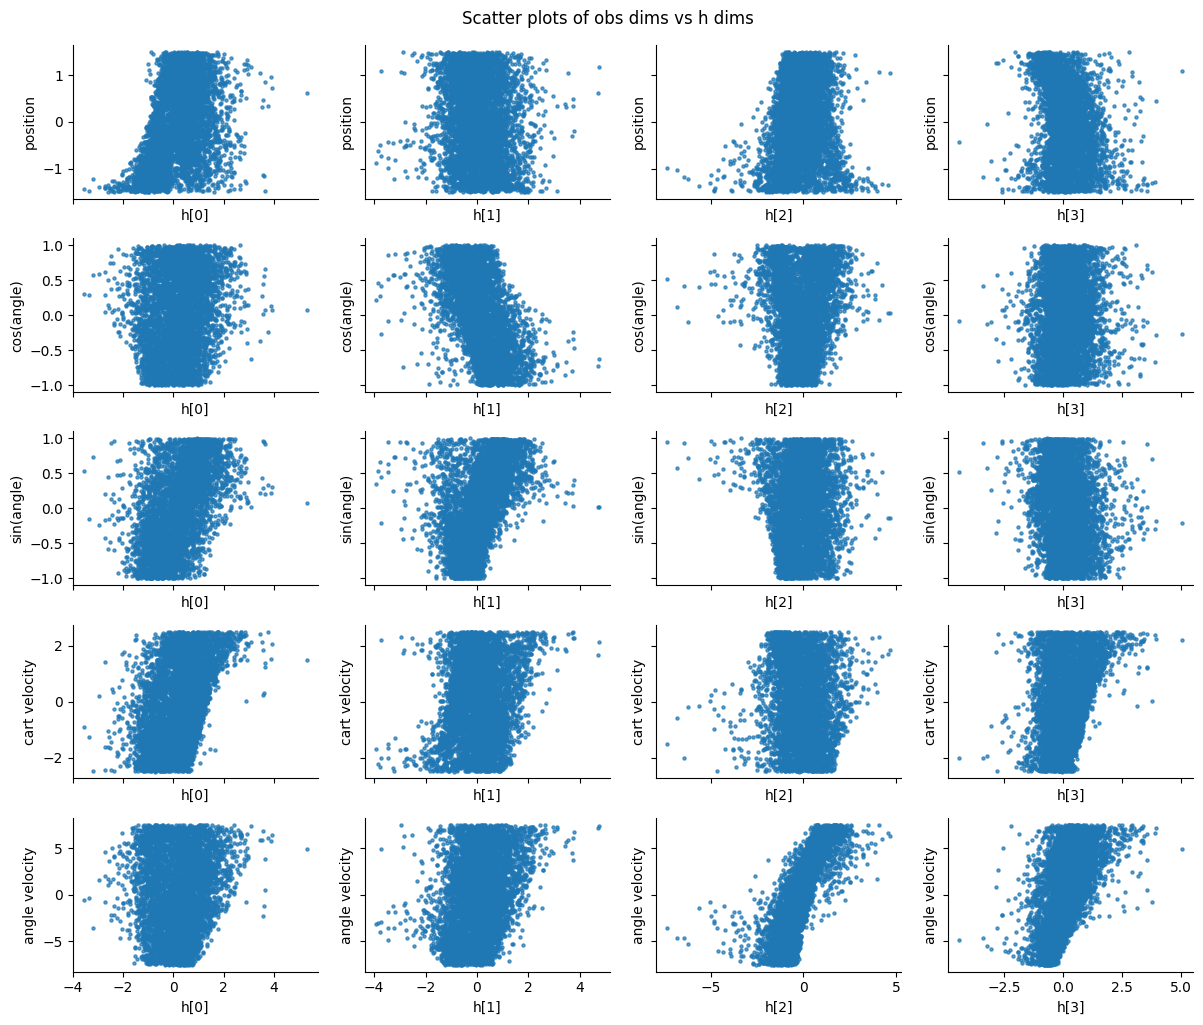

In [83]:
import matplotlib.pyplot as plt

obs_variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angle velocity'
}

obs_plot = obs_torch[:5_000]
h_plot = results_k[4]['h'][:5_000]

num_obs_dim = obs_plot.shape[1]
num_h_dim = h_plot.shape[1]

fig, axes = plt.subplots(
    num_obs_dim,
    num_h_dim,
    figsize=(3 * num_h_dim, 2 * num_obs_dim),
    sharex='col',  # share x-axis among columns (each h dim)
    sharey='row'  # share y-axis among rows (each obs dim)
)

for i in range(num_obs_dim):
    for j in range(num_h_dim):
        ax = axes[i, j] if num_obs_dim > 1 and num_h_dim > 1 else (
            axes[j] if num_obs_dim == 1 else axes[i])
        x = h_plot[:, j].cpu() if hasattr(h_plot[:, j], 'cpu') else h_plot[:, j]
        y = obs_plot[:, i]
        ax.scatter(x, y, s=5, alpha=0.7)
        ax.set_xlabel(f'h[{j}]')
        ax.set_ylabel(f'{obs_variable_names[i]}')

        # despine
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.suptitle("Scatter plots of obs dims vs h dims", y=1.02)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

obs_variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angle velocity'
}

episode = 4
obs_plot = obs[episode * 500:(episode + 1) * 500]
h_plot = h[episode * 500:(episode + 1) * 500]

num_obs_dim = obs_plot.shape[1]
num_h_dim = h_plot.shape[1]

# We'll color points by time
cmap = plt.get_cmap("viridis")
times = np.arange(obs_plot.shape[0])

plt.figure(figsize=(3 * num_h_dim, 3 * num_obs_dim))

for i in range(num_obs_dim):
    for j in range(num_h_dim):
        plt.subplot(num_obs_dim, num_h_dim, i * num_h_dim + j + 1)
        x = h_plot[:, j].cpu() if hasattr(h_plot[:, j], 'cpu') else h_plot[:, j]
        y = obs_plot[:, i]
        sc = plt.scatter(x, y, c=times, cmap=cmap, s=5, alpha=0.7)
        plt.xlabel(f'h[{j}]')
        plt.ylabel(f'{obs_variable_names[i]}')
        plt.tight_layout()

plt.suptitle("Scatter plots of obs dims vs h dims (colored by time)", y=1.02)
cbar = plt.colorbar(sc,
                    ax=plt.gcf().get_axes(),
                    orientation='vertical',
                    fraction=0.01,
                    pad=0.01)
cbar.set_label('Time step')
plt.show()